In [1]:
%load_ext autoreload
%autoreload 2

import torch
from tqdm import tqdm
import numpy as np
np.set_printoptions(precision=4, linewidth=10000, suppress=True)

from omegaconf import OmegaConf
from hydra import compose, initialize
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
import sys
sys.path.append('..') # add parent directory
# sys.path.append('../scaling-laws-ecnn/networks') # add parent directory
from networks.network_instantiation import run
from scaling.util import plot_model_data, binary_search_over_model_scaling

In [24]:
def run_test(overrides, verbose, image_size):
    # this is just a test function since gpu is not available right now
    depth = int(overrides[0].split("=")[1])
    width = float(overrides[1].split("=")[1])
    param_count = depth * width * image_size
    model_building_time = 10 * width + 0.5 * depth + 0.01 * image_size**2
    train_time = 0.1 * width + 0.01 * depth + 0.001 * image_size**2

    return param_count, model_building_time, train_time

In [3]:
# test memory footprint of {vs_param}
global_overrides = [
    "model=eq_wrn", 
    "dataset=imagenette",
    "model.restrict=[halved,invariant]",
    "model.kernel_layout=[3,3]", 
    "model.padding=1",
    "wandb.mode=disabled",
    "training.epochs=1",
    "model.rotation=8",
    "model.fix_params_mode=heuristic"
]

stats = {}
for mode in [[202,1], [58,1.9]]:
    mode_stats = []
    for image_size in range(32, 108, 10):

        overrides=[f"model.depth={mode[0]}",
                    f"model.widen_factor={mode[1]}",
                    f"dataset.resolution={image_size}"]
        overrides.extend(global_overrides)
        param_count, model_building_time, train_time = run(overrides=overrides, 
                                                            verbose=0)
        mode_stats.append([image_size, param_count, model_building_time, train_time])
        
    stats[f"Eq_wrn_{mode[0]}_{mode[1]}"] = np.array(mode_stats)

Eq_WRN_16_4.00_B(3,3)
Equivariant_WRN params: 2799413
Eq_WRN_16_4.00_B(3,3)
Equivariant_WRN params: 2822453
Eq_WRN_16_4.00_B(3,3)
Equivariant_WRN params: 2850613
Eq_WRN_16_4.00_B(3,3)
Equivariant_WRN params: 2922293
Eq_WRN_16_4.00_B(3,3)
Equivariant_WRN params: 2965813
Eq_WRN_16_4.00_B(3,3)
Equivariant_WRN params: 3014453
Eq_WRN_16_4.00_B(3,3)
Equivariant_WRN params: 3068213
Eq_WRN_16_4.00_B(3,3)
Equivariant_WRN params: 3191093
Eq_WRN_40_2.40_B(3,3)
Equivariant_WRN params: 2950173
Eq_WRN_40_2.40_B(3,3)
Equivariant_WRN params: 2964033
Eq_WRN_40_2.40_B(3,3)
Equivariant_WRN params: 2980973
Eq_WRN_40_2.40_B(3,3)
Equivariant_WRN params: 3024093
Eq_WRN_40_2.40_B(3,3)
Equivariant_WRN params: 3050273
Eq_WRN_40_2.40_B(3,3)
Equivariant_WRN params: 3079533
Eq_WRN_40_2.40_B(3,3)
Equivariant_WRN params: 3111873
Eq_WRN_40_2.40_B(3,3)
Equivariant_WRN params: 3185793


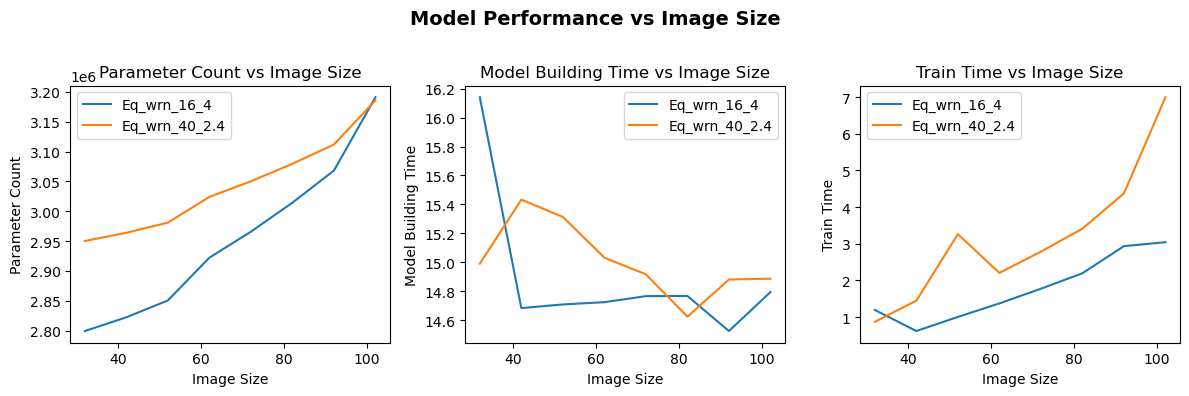

In [4]:
plot_model_data(stats, vs_param="Image Size")

In [15]:
# test depth scaling vs width scaling
global_args = [
        "model=eq_wrn", 
        "dataset=imagenette",
        "training=imagenette",
        "optimizer=RMSprop",
        "model.fix_params_mode=heuristic",
        "model.restrict=[halved,invariant]",
        "model.kernel_layout=[3,3]", 
        "model.padding=1",
        "wandb.tags=[eff_exp_1]",
        "model.rotation=8",
    ]

global_args_test = global_args + [
        "wandb.mode=disabled",
        "training.steps_per_epoch=10",
        "training.epochs=1",
    ]
image_size = 32
"""
stats = {}
mode_stats = []
for depth in range(6, 48, 6):
    overrides=[f"model.depth={depth+4}",
                f"model.widen_factor={1}",
                f"dataset.resolution={image_size}"]
    overrides.extend(global_args)
    param_count, model_building_time, train_time = run(overrides=overrides, 
                                                        verbose=0)
    mode_stats.append([depth, param_count, model_building_time, train_time])

stats[f"Eq_wrn_X_1"] = np.array(mode_stats)
"""
# width
mode_stats = []
for width in range(10, 50, 5):
        width = width / 10.0
        overrides=[f"model.depth={10}",
                    f"model.widen_factor={width}",
                    f"dataset.resolution={image_size}"]
        overrides.extend(global_args)
        param_count, model_building_time, train_time = run(overrides=overrides, 
                                                            verbose=0)
        mode_stats.append([width, param_count, model_building_time, train_time])
    
stats[f"Eq_wrn_10_X"] = np.array(mode_stats)

Eq_WRN_10_1.00_B(3,3)
Equivariant_WRN params: 97349
Eq_WRN_10_1.50_B(3,3)
Equivariant_WRN params: 211589
Eq_WRN_10_2.00_B(3,3)
Equivariant_WRN params: 369149
Eq_WRN_10_2.50_B(3,3)
Equivariant_WRN params: 570229
Eq_WRN_10_3.00_B(3,3)
Equivariant_WRN params: 808901
Eq_WRN_10_3.50_B(3,3)
Equivariant_WRN params: 1096061
Eq_WRN_10_4.00_B(3,3)
Equivariant_WRN params: 1426741
Eq_WRN_10_4.50_B(3,3)
Equivariant_WRN params: 1800941


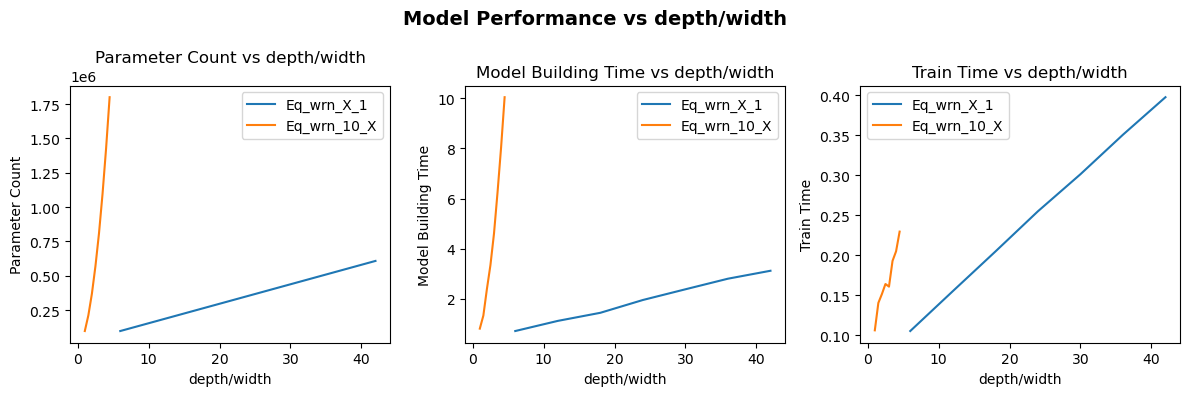

In [16]:
plot_model_data(stats, vs_param="depth/width")

In [7]:
# test memory footprint of rotation
global_overrides = [
    "model=eq_wrn", 
    "dataset=imagenette",
    "model.restrict=[halved,invariant]",
    "model.kernel_layout=[3,3]", 
    "model.padding=1",
    "wandb.tags=[eff_exp_1]",
    "wandb.mode=disabled",
    "training.epochs=1",
    "model.rotation=8",
    "model.fix_params_mode=heuristic"
]
image_size = 64

stats = {}
    
for mode in [[16,4], [40,2.4]]: # [[202,1], [58,1.9]]:
    mode_stats = []
    for rotation in range(2, 16, 2):
        overrides= [f"model.depth={mode[0]}",
                    f"model.widen_factor={mode[1]}",
                    f"dataset.resolution={108}",
                    f"model.rotation={rotation}"]
        overrides.extend(global_overrides)
        param_count, model_building_time, train_time = run(overrides=overrides, 
                                                            verbose=0)
        mode_stats.append([rotation, param_count, model_building_time, train_time])
        
    stats[f"Eq_wrn_{mode[0]}_{mode[1]}"] = np.array(mode_stats)

Eq_WRN_16_4.00_B(3,3)
Equivariant_WRN params: 3191093
Eq_WRN_16_4.00_B(3,3)
Equivariant_WRN params: 3191093
Eq_WRN_16_4.00_B(3,3)
Equivariant_WRN params: 3191093
Eq_WRN_16_4.00_B(3,3)
Equivariant_WRN params: 3191093
Eq_WRN_16_4.00_B(3,3)
Equivariant_WRN params: 3191093
Eq_WRN_16_4.00_B(3,3)
Equivariant_WRN params: 3191093
Eq_WRN_16_4.00_B(3,3)
Equivariant_WRN params: 3191093
Eq_WRN_40_2.40_B(3,3)
Equivariant_WRN params: 3185793
Eq_WRN_40_2.40_B(3,3)
Equivariant_WRN params: 3185793
Eq_WRN_40_2.40_B(3,3)
Equivariant_WRN params: 3185793
Eq_WRN_40_2.40_B(3,3)
Equivariant_WRN params: 3185793
Eq_WRN_40_2.40_B(3,3)
Equivariant_WRN params: 3185793
Eq_WRN_40_2.40_B(3,3)
Equivariant_WRN params: 3185793
Eq_WRN_40_2.40_B(3,3)
Equivariant_WRN params: 3185793


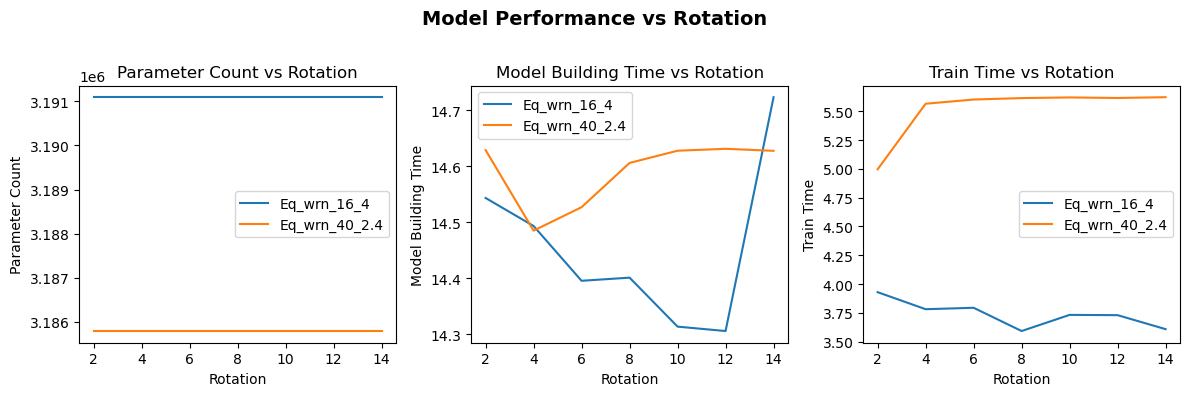

In [8]:
plot_model_data(stats, vs_param="Rotation")

# Scaling depth, width, image size

In [2]:
# find best suiting depth, width, resolution (search_param) for increasing 
# the model size, training time (scale_param) by 2 or 4 (scaling_factor).
scaling_factor = 2

global_overrides = {
    "model": "eq_wrn",
    "dataset": "imagenette",
    "model.restrict": ["halved", "invariant"],
    "model.kernel_layout": [3, 3],
    "model.padding": 1,
    "wandb.tags": ["eff_exp_1"],
    "wandb.mode": "disabled",
    "training.epochs": 1,
    "model.rotation": 8,
    "model.fix_params_mode": "heuristic",
}

def depth_constraint(depth):
    n = (depth - 4) // 6
    return 6 * n + 4

search_param = {"model.widen_factor": 1.0}
scale_param = {"train_time": 1}
initial_range = (search_param["model.widen_factor"], search_param["model.widen_factor"] * 2)
overrides = {"model.depth": 58, "dataset.resolution": 108}

best_depth = binary_search_over_model_scaling(search_param, scale_param, scaling_factor, 
                                              initial_range, depth_constraint,
                                              overrides, global_overrides)



/home/frischs/scaling-laws-ecnn/scaling/../networks/eq_wrn.py:91: UserWarning: Discretization artifacts are expected for rotation > 4 and                     kernel_layout = [3, 3].
  warnings.warn(f"Discretization artifacts are expected for rotation > 4 and \


Eq_WRN_58_1.000
Equivariant_WRN params: 876229
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
Eq_WRN_58_-2.000
E